DATA MANIPULATION


In [ ]:
import pandas as pd
df=pd.read_csv('/content/titanic uncleaned.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [ ]:
df.shape

(418, 12)

In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [ ]:
df['Age_mean_imputed']=df['Age'].fillna(df['Age'].mean())

In [ ]:
df['Age_median_imputed']=df['Age'].fillna(df['Age'].median())

In [ ]:
df['Cabin_mode_imputed']=df['Cabin'].fillna(df['Cabin'].mode()[0])

In [ ]:
df[['Age','Age_mean_imputed','Age_median_imputed','Cabin']]

,Age,Age_mean_imputed,Age_median_imputed,Cabin
0,34.5,34.50000,34.5,NaN
1,47.0,47.00000,47.0,NaN
2,62.0,62.00000,62.0,NaN
3,27.0,27.00000,27.0,NaN
4,22.0,22.00000,22.0,NaN
...,...,...,...,...
413,NaN,30.27259,27.0,NaN
414,39.0,39.00000,39.0,C105
415,38.5,38.50000,38.5,NaN
416,NaN,30.27259,27.0,NaN


In [ ]:
df.duplicated().sum()

np.int64(0)

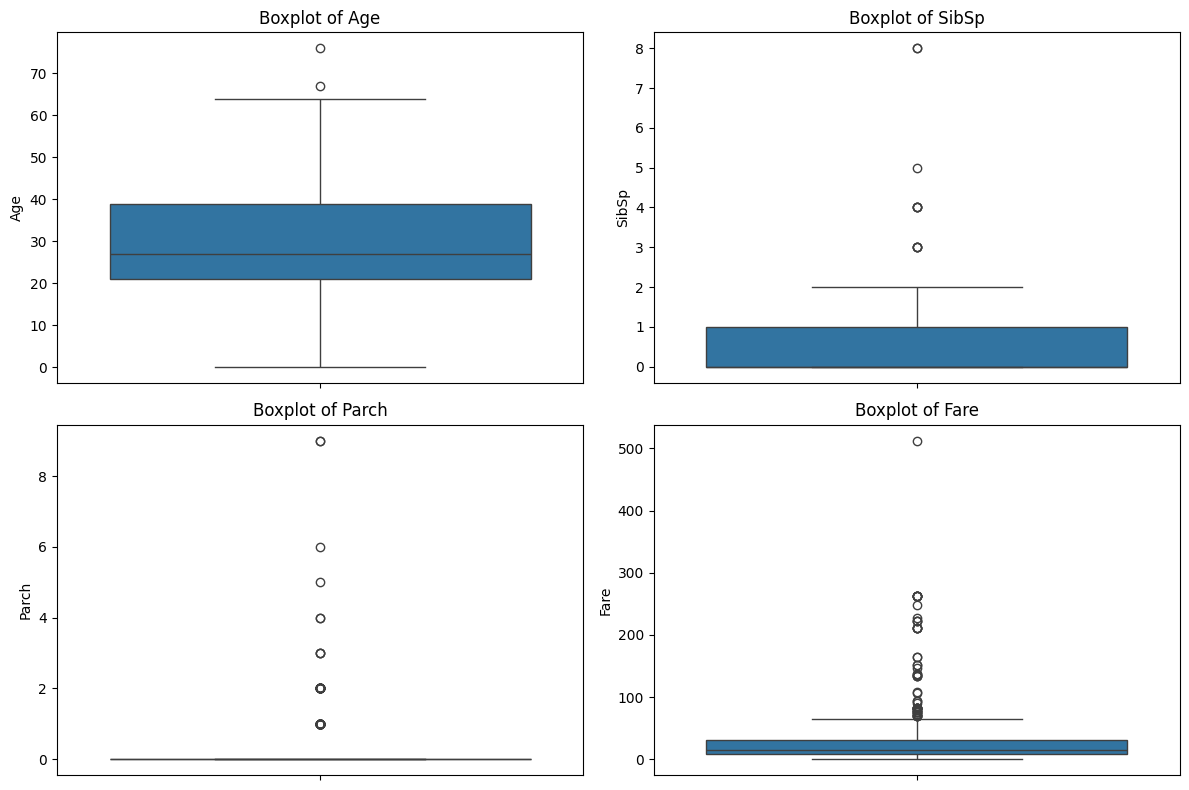

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cols=['Age','SibSp','Parch','Fare']
plt.figure(figsize=(12,8))

for i,col in enumerate(cols,1):
  plt.subplot(2,2,i)
  sns.boxplot(y=df[col])
  plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [ ]:
df_clean=df.copy()

for cols in cols:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)

  IQR=Q3-Q1

  lower_limit=Q1-1.5*IQR
  upper_limit=Q3+1.5*IQR

  df_clean=df_clean[
      (df_clean[col]>=lower_limit)&
      (df_clean[col]<=upper_limit)

  ]
  print("original shape:",df.shape)
  print("after outlier removal:",df_clean.shape)

original shape: (418, 15)
after outlier removal: (362, 15)
original shape: (418, 15)
after outlier removal: (362, 15)
original shape: (418, 15)
after outlier removal: (362, 15)
original shape: (418, 15)
after outlier removal: (362, 15)


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

encoded_data=df.copy()

In [ ]:
label_encoder=LabelEncoder()
encoded_data['Sex_Label']=label_encoder.fit_transform(encoded_data['Sex'])

one_hot_encoded=pd.get_dumies(encoded_data['Embarked'],prefix='Embarked')
encoded_data=pd.concat([encoded_data,one_hot_encoded],axis=1)

pclass_mapping={1:'First',2:'Second',3:'Third'}
print(encoded_data[['Sex','Sex_Label','Embarked','Embarked_Q','Embarked_S','Embarked_C',]])

